In [ ]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image

import pathlib

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torch

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

In [ ]:
import os
import glob
from sklearn.model_selection import train_test_split
import shutil
from pathlib import Path

# --- 1. 경로 설정 ---
# 원본 CUB_200_2011 데이터셋 경로 (images 폴더가 있는 경로)
original_dataset_dir = '../../data/CUB_200_2011/images'

# 데이터를 새로 저장할 기본 경로
base_dir = Path('../../data/CUB_200_2011_split')
if not os.path.exists(base_dir):
    os.mkdir(base_dir)

# 훈련, 검증 디렉토리 경로 설정
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

if not os.path.exists(train_dir):
    os.mkdir(train_dir)
if not os.path.exists(validation_dir):
    os.mkdir(validation_dir)

# --- 2. 품종 목록 가져오기 ---
# 원본 데이터셋의 품종 폴더 목록을 가져옵니다.
try:
    breeds = os.listdir(original_dataset_dir)
    # .DS_Store와 같은 시스템 파일을 목록에서 제거
    breeds = [b for b in breeds if not b.startswith('.')]
except FileNotFoundError:
    raise FileNotFoundError(f"오류: 원본 데이터셋 폴더를 찾을 수 없습니다. 경로를 확인해주세요: {os.path.abspath(original_dataset_dir)}")

# --- 3. 훈련/검증 데이터 분할 및 복사 ---
print("데이터 분할 및 복사를 시작합니다...")

for breed_folder in breeds:
    # 각 품종별로 훈련 및 검증 폴더 생성
    train_breed_dir = os.path.join(train_dir, breed_folder)
    validation_breed_dir = os.path.join(validation_dir, breed_folder)
    os.makedirs(train_breed_dir, exist_ok=True)
    os.makedirs(validation_breed_dir, exist_ok=True)

    # 원본 품종 폴더 경로
    src_dir = os.path.join(original_dataset_dir, breed_folder)

    # ▼▼▼▼▼ 핵심 수정사항 ▼▼▼▼▼
    # .jpg, .jpeg, .png 등 다양한 확장자를 모두 검색합니다.
    image_files = []
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(src_dir, ext)))
    # ▲▲▲▲▲ 여기까지 수정 ▲▲▲▲▲

    # (안전장치) 만약 폴더에 이미지가 없다면, 경고를 출력하고 다음 폴더로 넘어갑니다.
    if len(image_files) == 0:
        print(f"경고: '{breed_folder}' 폴더에서 이미지를 찾을 수 없습니다. 이 폴더는 건너뜁니다.")
        continue # 다음 루프로 넘어감

    # train_test_split을 사용하여 8:2 비율로 파일 목록 분할
    train_files, val_files = train_test_split(image_files, test_size=0.2, random_state=42)

    # 훈련 데이터 복사
    for f in train_files:
        shutil.copy(f, os.path.join(train_breed_dir, os.path.basename(f)))

    # 검증 데이터 복사
    for f in val_files:
        shutil.copy(f, os.path.join(validation_breed_dir, os.path.basename(f)))

    print(f"'{breed_folder}' 완료: 훈련({len(train_files)}), 검증({len(val_files)})")

print(f"\n데이터 분할 완료! '{base_dir}' 폴더를 확인해주세요.")


In [10]:
from torchvision import transforms

# EfficientNet-B5
resize = 456
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

#데이터 로더 구조 정의
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]

In [11]:
BATCH_SIZE=64

#데이터 로더 정의
transform= Make_dataset_Transform(resize,mean,std)
기준경로 = pathlib.Path('../../data/CUB_200_2011_split')

tr_ds=datasets.ImageFolder(기준경로/'train',transform=transform('train'))
val_ds=datasets.ImageFolder(기준경로/'validation',transform=transform('val'))

tr_ds_loader=DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

In [12]:
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
ef_m = efficientnet_b5(weights=EfficientNet_B5_Weights.IMAGENET1K_V1)
ef_m

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [13]:
ef_m.features.parameters()
for p in ef_m.features.parameters() :
    p.requires_grad = False

for layer in ef_m.features[-2:]:
    for p in layer.parameters():
        p.requires_grad = True

In [14]:
# 동결 해제 상태 확인
print("\n--- 파라미터 requires_grad 상태 ---")
for i, layer in enumerate(ef_m.features):
    if i == 0 or i >= len(ef_m.features) - 2:
        print(f"Layer {i}: requires_grad = {next(layer.parameters()).requires_grad}")


--- 파라미터 requires_grad 상태 ---
Layer 0: requires_grad = False
Layer 7: requires_grad = True
Layer 8: requires_grad = True


In [15]:
class_n = 200
classifier_in_n = ef_m.classifier[-1].in_features
ef_m.classifier[-1] = nn.Linear(classifier_in_n, class_n)
ef_m

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [16]:
from torch.optim.lr_scheduler import CosineAnnealingLR
EPOCH = 100

ef_m = ef_m.to(DEVICE)
criterion = nn.CrossEntropyLoss()
opt = optim.AdamW([
    {'params': ef_m.features[:-4].parameters(), 'lr': 1e-6},
    {'params': ef_m.features[-4:-2].parameters(), 'lr': 5e-6},
    {'params': ef_m.features[-2:].parameters(), 'lr': 1e-5},
    {'params': ef_m.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-2)

scheduler = CosineAnnealingLR(opt, T_max=EPOCH//2, eta_min=1e-7)

In [9]:
# 하이퍼파라미터 및 경로 설정

best_val_loss = float('inf')
best_model_path = "best_ef_m.pth"

# 얼리 스톱을 위한 변수
patience = 10  # 성능 개선이 없는 최대 에포크 횟수
counter = 0    # 성능 개선이 없는 에포크 카운터

# 손실 및 정확도 값을 저장할 리스트
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

def run_epoch(m, loder, train=True):
    m.train(train)
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loder:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train):
            output = m(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                opt.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (output.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, total_correct / total

print("모델 학습을 시작합니다...")
for i in range(1, EPOCH + 1):
    tr_loss, tr_acc = run_epoch(ef_m, tr_ds_loader, True)
    val_loss, val_acc = run_epoch(ef_m, val_ds_loader, False)

    scheduler.step()
    
    # 각 에포크의 손실과 정확도를 리스트에 추가
    train_losses.append(tr_loss)
    train_accuracies.append(tr_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch {i}/{EPOCH} | tr_loss: {tr_loss:.4f}, tr_acc: {tr_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

    # 베스트 모델 저장 및 얼리 스톱 로직
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ef_m.state_dict(), best_model_path)
        print(f"→ New best model saved (val_loss: {best_val_loss:.4f})")
        counter = 0  # 성능 개선 시 카운터 초기화
    else:
        counter += 1  # 성능 개선 없을 시 카운터 증가
        print(f"Early Stopping Counter: {counter}/{patience}")

    if counter >= patience:
        print(f"\n→ Validation accuracy has not improved for {patience} epochs. Stopping training early.")
        break  # 학습 루프 종료

print("\n모델 학습이 완료되었습니다.")

모델 학습을 시작합니다...
Epoch 1/100 | tr_loss: 5.1193, tr_acc: 0.0731 | val_loss: 4.7484, val_acc: 0.3076
→ New best model saved (val_loss: 4.7484)
Epoch 2/100 | tr_loss: 4.5560, tr_acc: 0.3013 | val_loss: 3.9765, val_acc: 0.4647
→ New best model saved (val_loss: 3.9765)
Epoch 3/100 | tr_loss: 3.8774, tr_acc: 0.4618 | val_loss: 3.3060, val_acc: 0.5324
→ New best model saved (val_loss: 3.3060)
Epoch 4/100 | tr_loss: 3.2367, tr_acc: 0.5502 | val_loss: 2.7499, val_acc: 0.5979
→ New best model saved (val_loss: 2.7499)
Epoch 5/100 | tr_loss: 2.7215, tr_acc: 0.6129 | val_loss: 2.3505, val_acc: 0.6416
→ New best model saved (val_loss: 2.3505)
Epoch 6/100 | tr_loss: 2.3231, tr_acc: 0.6502 | val_loss: 2.0309, val_acc: 0.6693
→ New best model saved (val_loss: 2.0309)
Epoch 7/100 | tr_loss: 2.0305, tr_acc: 0.6899 | val_loss: 1.7891, val_acc: 0.6929
→ New best model saved (val_loss: 1.7891)
Epoch 8/100 | tr_loss: 1.7929, tr_acc: 0.7124 | val_loss: 1.5972, val_acc: 0.7223
→ New best model saved (val_loss: 

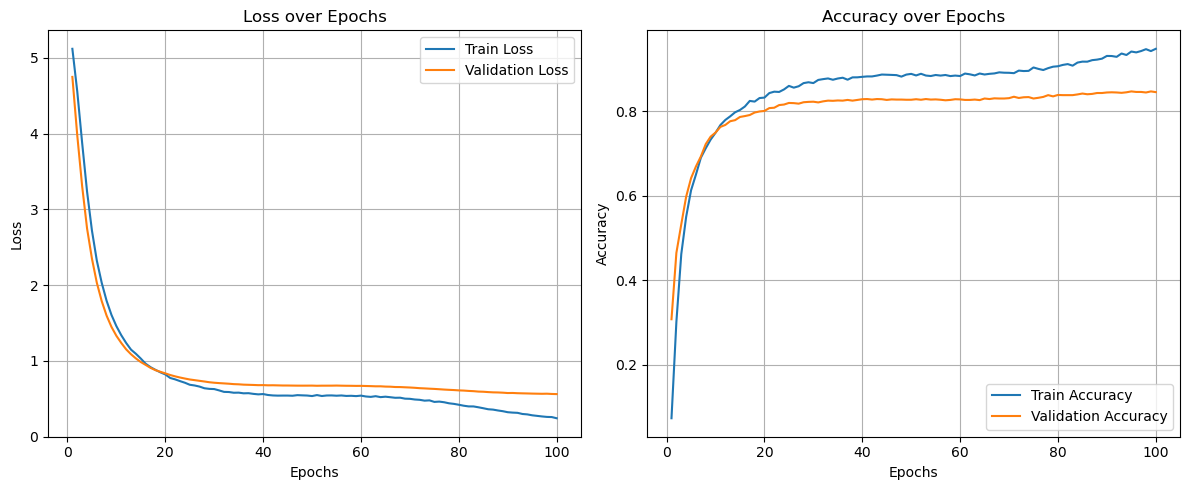

In [10]:
import matplotlib.pyplot as plt

actual_epochs = len(train_losses)
epochs_list = list(range(1, actual_epochs + 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, label='Train Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_accuracies, label='Train Accuracy')
plt.plot(epochs_list, val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
def evaluate_topk(model, loader, topk=(1, 5, 10)):
    """
    주어진 모델과 데이터 로더에 대해 Top-k 정확도를 계산합니다.
    """
    model.eval() # 모델을 평가 모드로 전환
    
    with torch.no_grad():
        correct_counts = {k: 0 for k in topk}
        total = 0

        for x, y in loader:
            x, y = x.to(model.classifier[-1].weight.device), y.to(model.classifier[-1].weight.device)
            output = model(x)
            total += y.size(0)

            # 상위 k개 예측 결과의 인덱스를 가져옵니다.
            maxk = max(topk)
            _, pred = output.topk(maxk, 1, True, True)
            pred = pred.t() # 텐서의 형태를 (maxk, batch_size)로 변환

            # 각 k에 대해 정확도를 계산합니다.
            for k in topk:
                # pred의 상위 k개와 정답 레이블(y)을 비교
                correct = pred[:k].eq(y.view(1, -1).expand_as(pred[:k]))
                
                # 상위 k개 중 하나라도 정답인 샘플의 수를 합산합니다.
                correct_k = correct.reshape(-1).float().sum(0, keepdim=True)
                correct_counts[k] += correct_k.item()

        accuracies = {k: (count / total) * 100 for k, count in correct_counts.items()}
        return accuracies

# 성능 지표 계산 및 출력
print("최종 모델 성능 평가 시작...")
best_model_path = './best_ef_m.pth'
ef_m.load_state_dict(torch.load(best_model_path))
final_accuracies = evaluate_topk(ef_m, val_ds_loader, topk=(1, 5, 10))

print("\n--- 최종 성능 지표 ---")
print(f"Top-1 정확도: {final_accuracies[1]:.2f}%")
print(f"Top-5 정확도: {final_accuracies[5]:.2f}%")
print(f"Top-10 정확도: {final_accuracies[10]:.2f}%")

최종 모델 성능 평가 시작...

--- 최종 성능 지표 ---
Top-1 정확도: 84.54%
Top-5 정확도: 96.89%
Top-10 정확도: 98.61%


In [22]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np # numpy import 추가

def visualize_topk_predictions(model, dataset, device, class_names, n_images=10, k=5):
    """
    ⭐️ 수정됨: DataLoader 대신 Dataset에서 직접 이미지를 랜덤 샘플링하여 시각화합니다.
    """
    model.eval()
    plt.figure(figsize=(20, 10))

    # 1. 데이터셋의 전체 크기 내에서 n_images개의 랜덤 인덱스를 선택합니다.
    indices = torch.randperm(len(dataset))[:n_images]

    # 2. 선택된 인덱스를 사용하여 이미지와 정답을 리스트에 담습니다.
    images, targets = [], []
    for idx in indices:
        image, target = dataset[idx]
        images.append(image)
        targets.append(target)

    # 3. 이미지 리스트를 하나의 배치 텐서로 만듭니다.
    data = torch.stack(images).to(device)
    target = torch.tensor(targets).to(device)

    with torch.no_grad():
        output = model(data)
        probabilities, preds = F.softmax(output, dim=1).topk(k, 1, True, True)

        for i in range(len(data)):
            # 이미지 복원
            img = data[i].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # 서브플롯 설정
            plt.subplot(2, n_images // 2, i + 1)
            plt.imshow(img)
            plt.axis('off')

            true_label = class_names[target[i].item()]

            # 예측 결과 포맷팅
            pred_list = []
            for j in range(k):
                pred_label = class_names[preds[i][j].item()]
                prob = probabilities[i][j].item() * 100
                pred_list.append(f"{pred_label} ({prob:.2f}%)")

            pred_text = '\n'.join(pred_list)
            plt.title(f'True: {true_label}\nTop-{k} Preds:\n{pred_text}', fontsize=9)

    plt.tight_layout()
    plt.show()

모델 가중치를 성공적으로 불러왔습니다: ./best_ef_m.pth


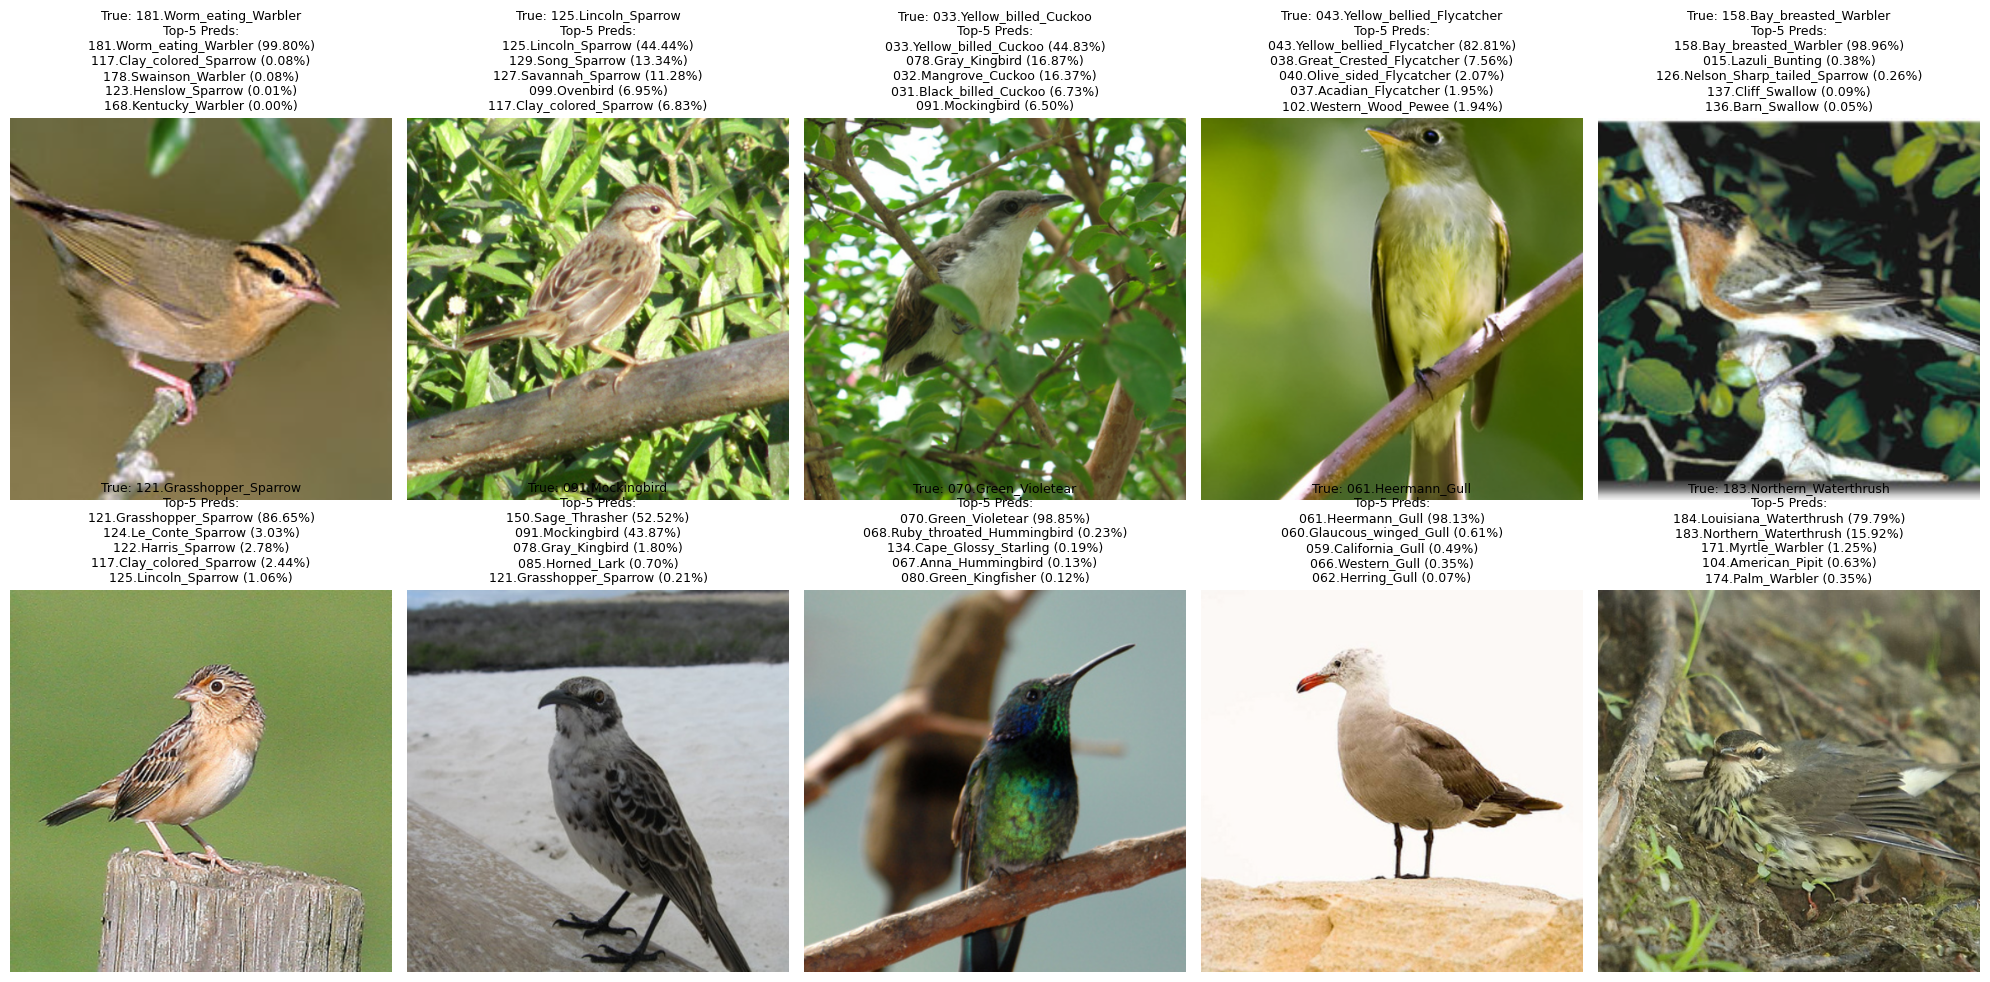

In [23]:
best_model_path = "./best_ef_m.pth"

try:
    ef_m.load_state_dict(torch.load(best_model_path))
    print(f"모델 가중치를 성공적으로 불러왔습니다: {best_model_path}")
except FileNotFoundError:
    print(f"오류: '{best_model_path}' 파일을 찾을 수 없습니다. 학습이 완료되었는지 확인해주세요.")

ef_m.eval()

class_names = val_ds.classes

visualize_topk_predictions(
    model=ef_m,
    dataset=val_ds,
    device=DEVICE,
    class_names=class_names,
    n_images=10,
    k=5
)